In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split

In [2]:
import pyecoacc as acc 
from pyecoacc.models.pipeline import get_default_random_forest_pipeline
from pyecoacc.util.analytics import compute_confusion_matrix
from pyecoacc.util.time_budget import compute_time_budget
from pyecoacc.util.training import train_compute_cm

# Load 

This is only for the demonstration, don't do this for actual model training! 
- Take first 150 of each behavior for training (train)
- Take next 150 of each behavior for confusion matrix estimation (val)
- All remaining samples will be used for time budgets 

In [3]:
molerats_data = pd.read_csv("data/molerats.csv", index_col=0)

molerats_data = molerats_data.sample(frac=1)  # shuffle 
molerats_data.drop("Animal", inplace=True, axis=1)

train = molerats_data.groupby("Behavior").head(150).copy()
val = molerats_data.groupby("Behavior").apply(lambda x: x.iloc[150:300]).copy()
for_time_budget = molerats_data.groupby("Behavior").apply(lambda x: x.iloc[200:]).copy()

# Model 

In [4]:
model = get_default_random_forest_pipeline()

In [5]:
X = train.iloc[:, :-1].values 
y = train.Behavior.values 
model.fit(X, y)

Pipeline(steps=[('features', ACCStatsTransformer()),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=250))])

In [6]:
X_test = val.iloc[:, :-1].values 
y_test = val.Behavior.values 
y_hat = model.predict(X_test)

cm = compute_confusion_matrix(y_test, y_hat)
cm

,Dig,Eat,Forward Loco,Rest,Stand,Sweep
Dig,0.83,0.03,0.07,0.00,0.00,0.07
Eat,0.01,0.85,0.05,0.00,0.08,0.01
Forward Loco,0.11,0.07,0.73,0.01,0.05,0.03
Rest,0.00,0.00,0.00,0.91,0.09,0.00
Stand,0.04,0.15,0.08,0.03,0.69,0.01
Sweep,0.07,0.02,0.10,0.00,0.02,0.79


# Compute time budgets 
- show real (ground truth) tb 
- show estimated with and without confusion matrix correction 

In [7]:
real_tb = for_time_budget.Behavior.value_counts(normalize=True)

In [8]:
X = for_time_budget.iloc[:, :-1].values 

In [9]:
estimated_tb_with_cm = compute_time_budget(X, model, cm)
estimated_tb_without_cm = compute_time_budget(X, model, cm=None, apply_cm_correction=False)

<Axes: >

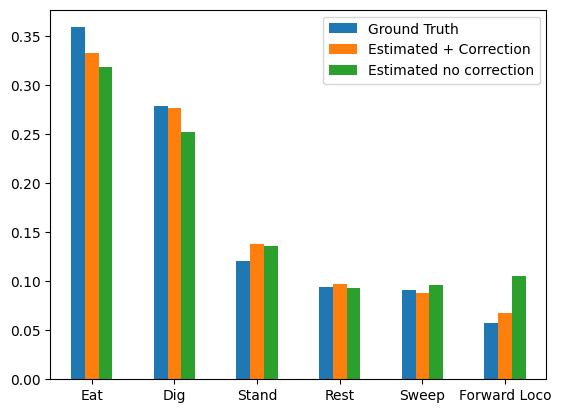

In [10]:
pd.DataFrame([real_tb, estimated_tb_with_cm, estimated_tb_without_cm], 
             index=["Ground Truth", "Estimated + Correction", "Estimated no correction"]).T.plot(kind="bar", rot=0)

# Shortcut 
- Split only into training (model training + confusion matrix estimate) and test (compute time-budgets) data 
- Using the pyecoacc utility `train_compute_cm` for taining and confusion matrix computation in a single step 

*notice this time we are using much more data for training (50%) so the resulting model is better*

In [11]:
molerats_data = pd.read_csv("data/molerats.csv", index_col=0)
molerats_data.drop("Animal", inplace=True, axis=1)
X = molerats_data.iloc[:, :-1].values 
y = molerats_data.Behavior.values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.5)

In [12]:
model = get_default_random_forest_pipeline()

In [13]:
cm = train_compute_cm(model, X_train, y_train)

In [14]:
cm

,Dig,Eat,Forward Loco,Rest,Stand,Sweep
Dig,0.90,0.03,0.03,0.00,0.00,0.03
Eat,0.02,0.93,0.01,0.00,0.02,0.02
Forward Loco,0.17,0.29,0.40,0.00,0.00,0.14
Rest,0.00,0.00,0.00,0.94,0.06,0.00
Stand,0.04,0.29,0.01,0.04,0.62,0.00
Sweep,0.16,0.05,0.09,0.00,0.00,0.70


In [15]:
real_tb = pd.Series(y_test).value_counts(normalize=True)
estimated_tb_with_cm = compute_time_budget(X_test, model, cm)
estimated_tb_without_cm = compute_time_budget(X_test, model, cm=None, apply_cm_correction=False)

<Axes: >

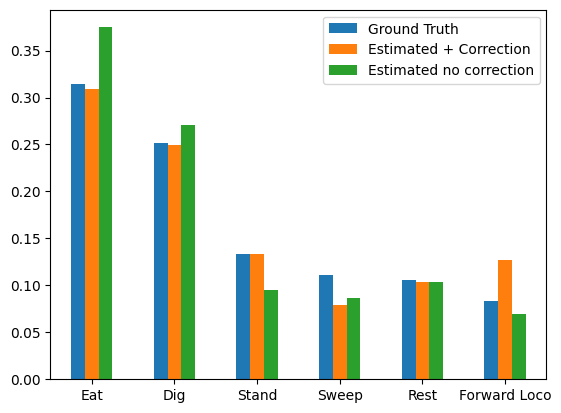

In [16]:
pd.DataFrame([real_tb, estimated_tb_with_cm, estimated_tb_without_cm], 
             index=["Ground Truth", "Estimated + Correction", "Estimated no correction"]).T.plot(kind="bar", rot=0)